<a href="https://colab.research.google.com/github/rfpmaa/uas-ml/blob/main/notebook/UAS_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
url = "https://raw.githubusercontent.com/rfpmaa/uas-ml/main/dataset/beasiswa.csv"

df = pd.read_csv(url)

df.head()

,IPK,Semester,Penghasilan_Ortu,Tanggungan_Keluarga,Prestasi,Aktif_Organisasi,Status_Rumah,Jenis_Kelamin,Diterima_Beasiswa
0,3.37,2,2000000,3,Internasional,Tidak,Milik Sendiri,P,0
1,3.15,5,4000000,6,Tidak Ada,Ya,Kos/Asrama,P,1
2,3.43,3,1500000,6,Provinsi,Ya,Kontrak,P,1
3,3.73,6,1000000,5,Tidak Ada,Tidak,Milik Sendiri,L,1
4,3.12,2,500000,1,Tidak Ada,Tidak,Milik Sendiri,P,1


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   IPK                  300 non-null    float64
 1   Semester             300 non-null    int64  
 2   Penghasilan_Ortu     300 non-null    int64  
 3   Tanggungan_Keluarga  300 non-null    int64  
 4   Prestasi             300 non-null    object 
 5   Aktif_Organisasi     300 non-null    object 
 6   Status_Rumah         300 non-null    object 
 7   Jenis_Kelamin        300 non-null    object 
 8   Diterima_Beasiswa    300 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 21.2+ KB


In [51]:
df.describe()

,IPK,Semester,Penghasilan_Ortu,Tanggungan_Keluarga,Diterima_Beasiswa
count,300.000000,300.000000,3.000000e+02,300.000000,300.000000
mean,3.195400,4.906667,2.065000e+06,3.396667,0.706667
std,0.336704,1.999487,1.283393e+06,1.701658,0.456051
min,2.070000,2.000000,5.000000e+05,1.000000,0.000000
25%,2.960000,3.000000,1.000000e+06,2.000000,0.000000
50%,3.220000,5.000000,1.500000e+06,3.000000,1.000000
75%,3.420000,6.000000,3.000000e+06,5.000000,1.000000
max,4.000000,8.000000,6.000000e+06,6.000000,1.000000


In [52]:
print("Jumlah Baris dan Kolom :", df.shape)

Jumlah Baris dan Kolom : (300, 9)


In [53]:
df.dtypes

,0
IPK,float64
Semester,int64
Penghasilan_Ortu,int64
Tanggungan_Keluarga,int64
Prestasi,object
Aktif_Organisasi,object
Status_Rumah,object
Jenis_Kelamin,object
Diterima_Beasiswa,int64


In [54]:
# Cek missing values
df.isnull().sum()

,0
IPK,0
Semester,0
Penghasilan_Ortu,0
Tanggungan_Keluarga,0
Prestasi,0
Aktif_Organisasi,0
Status_Rumah,0
Jenis_Kelamin,0
Diterima_Beasiswa,0


In [55]:
# Cek data duplikat
df.duplicated().sum()

np.int64(0)

In [56]:
df["Diterima_Beasiswa"].value_counts()

,count
Diterima_Beasiswa,
1,212
0,88


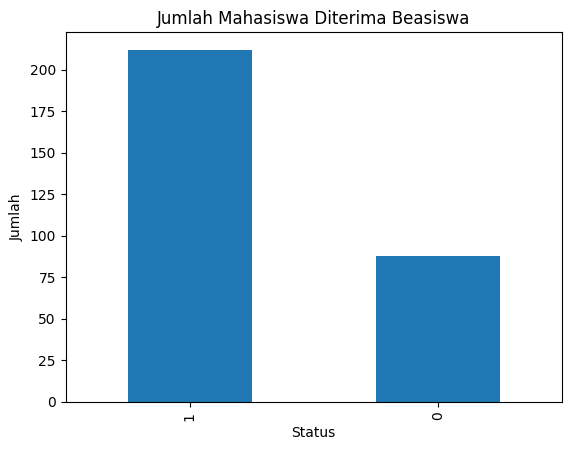

In [57]:
df["Diterima_Beasiswa"].value_counts().plot(kind="bar")

plt.title("Jumlah Mahasiswa Diterima Beasiswa")
plt.xlabel("Status")
plt.ylabel("Jumlah")
plt.show()

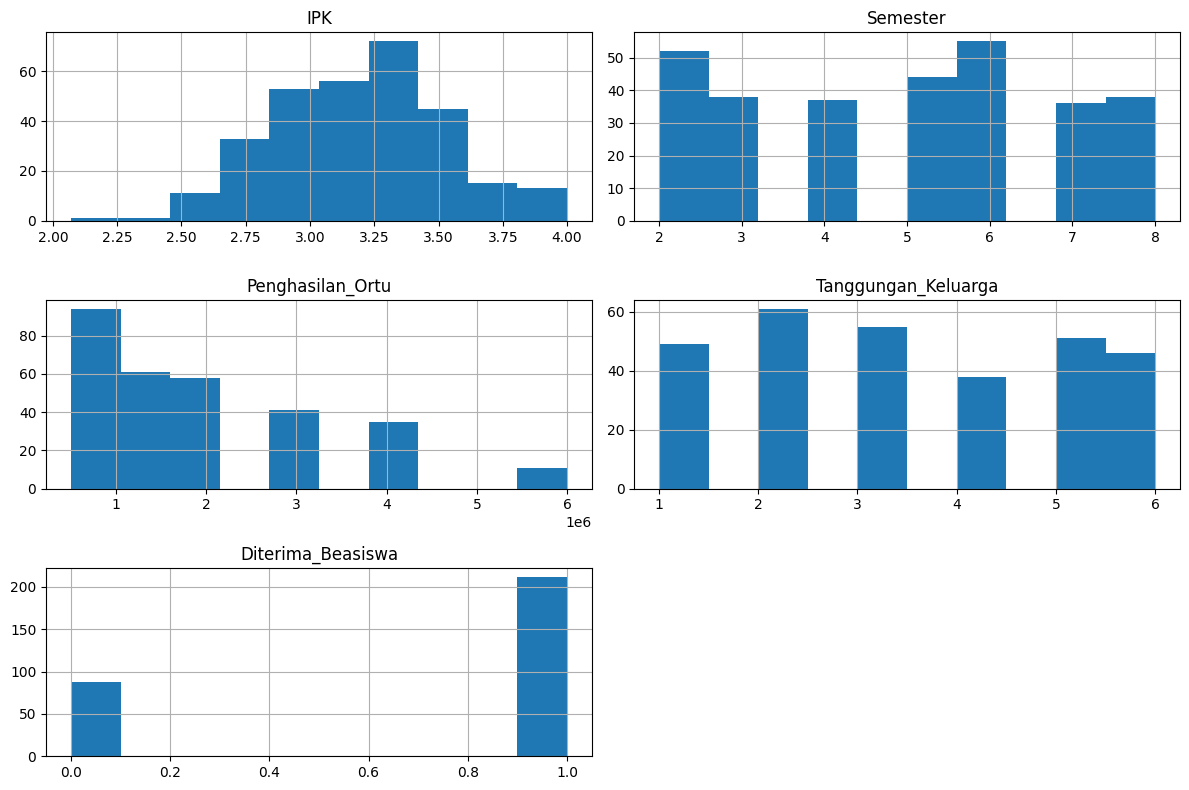

In [58]:
df.hist(figsize=(12,8))

plt.tight_layout()

plt.show()

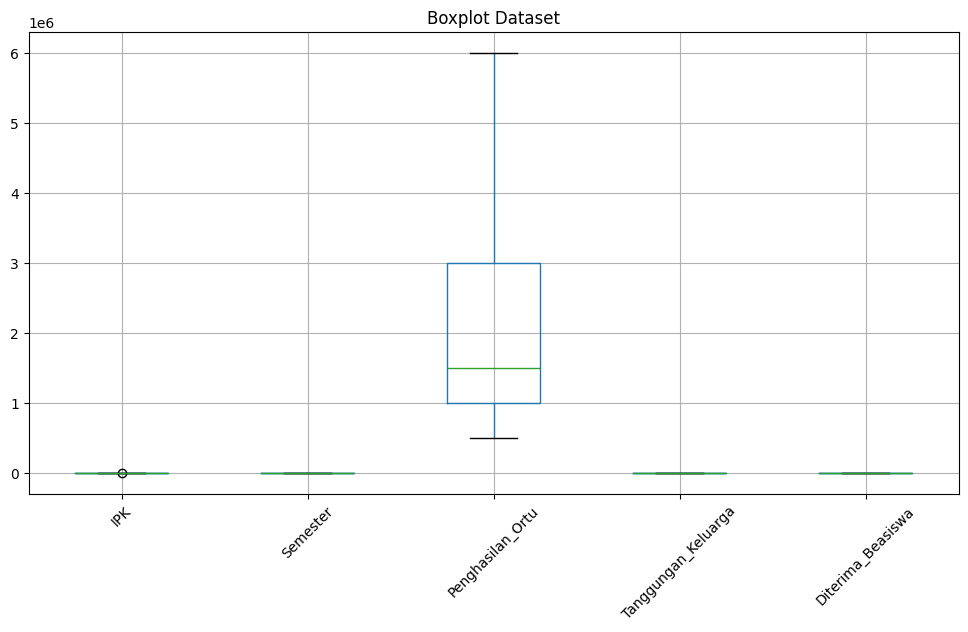

In [59]:
plt.figure(figsize=(12,6))

df.boxplot()

plt.xticks(rotation=45)

plt.title("Boxplot Dataset")

plt.show()

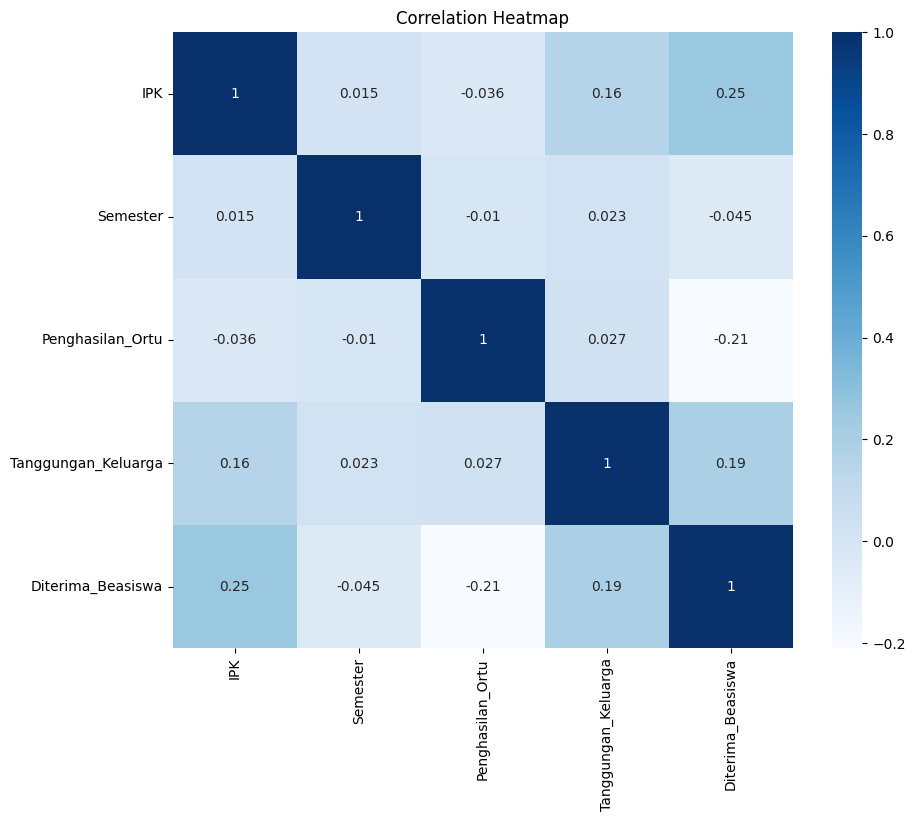

In [60]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [61]:
from sklearn.preprocessing import LabelEncoder

df_encode = df.copy()

le = LabelEncoder()

categorical_cols = [
    'Prestasi',
    'Aktif_Organisasi',
    'Status_Rumah',
    'Jenis_Kelamin',
    'Diterima_Beasiswa'
]

for col in categorical_cols:
    df_encode[col] = le.fit_transform(df_model[col])

df_encode.head()

,IPK,Semester,Penghasilan_Ortu,Tanggungan_Keluarga,Prestasi,Aktif_Organisasi,Status_Rumah,Jenis_Kelamin,Diterima_Beasiswa
0,3.37,2,2000000,3,0,0,3,1,0
1,3.15,5,4000000,6,4,1,1,1,1
2,3.43,3,1500000,6,3,1,0,1,1
3,3.73,6,1000000,5,4,0,3,0,1
4,3.12,2,500000,1,4,0,3,1,1


In [62]:
X = df_model.drop("Diterima_Beasiswa", axis=1)
y = df_model["Diterima_Beasiswa"]

print("Jumlah fitur :", X.shape)
print("Jumlah target :", y.shape)

Jumlah fitur : (300, 8)
Jumlah target : (300,)


In [63]:
from sklearn.model_selection import train_test_split

X = df_encode.drop("Diterima_Beasiswa", axis=1)
y = df_encode["Diterima_Beasiswa"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest berhasil dilatih!")

Random Forest berhasil dilatih!


In [65]:
y_pred_rf = rf.predict(X_test)

In [66]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.7333333333333333

Classification Report

              precision    recall  f1-score   support

           0       0.62      0.28      0.38        18
           1       0.75      0.93      0.83        42

    accuracy                           0.73        60
   macro avg       0.69      0.60      0.61        60
weighted avg       0.71      0.73      0.70        60



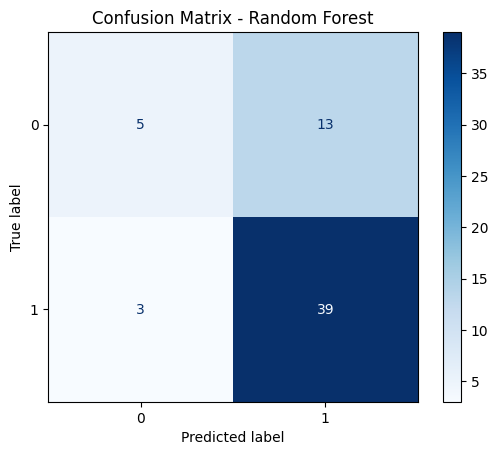

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [68]:
plt.savefig("confusion_matrix_rf.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

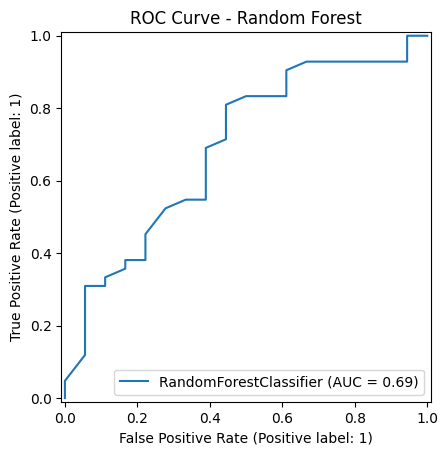

In [69]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")
plt.show()

In [70]:
plt.savefig("roc_curve_rf.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

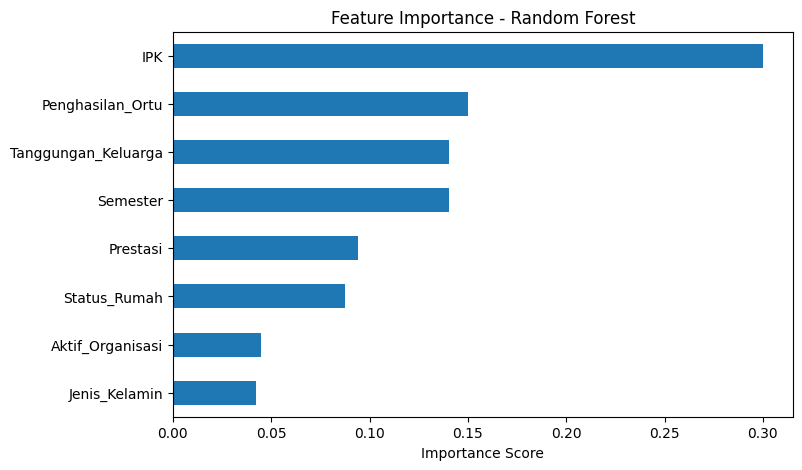

In [71]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,5))
importance.plot(kind="barh")

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

In [72]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

print("SVM berhasil dilatih!")

SVM berhasil dilatih!


In [73]:
y_pred_svm = svm.predict(X_test)

In [74]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy SVM :", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_svm, zero_division=0))

Accuracy SVM : 0.7

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        18
           1       0.70      1.00      0.82        42

    accuracy                           0.70        60
   macro avg       0.35      0.50      0.41        60
weighted avg       0.49      0.70      0.58        60



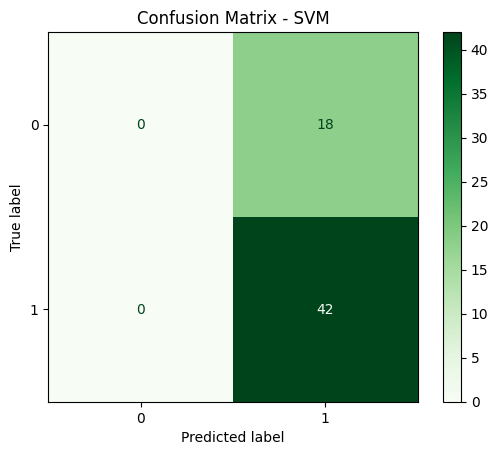

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    svm,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("Confusion Matrix - SVM")
plt.show()

In [76]:
plt.savefig("confusion_matrix_svm.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

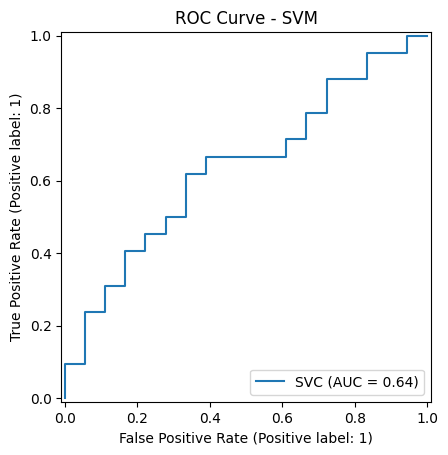

In [77]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    svm,
    X_test,
    y_test
)

plt.title("ROC Curve - SVM")
plt.show()

In [78]:
plt.savefig("roc_curve_svm.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [79]:
import pandas as pd
from sklearn.metrics import accuracy_score

hasil = pd.DataFrame({
    'Model': ['Random Forest', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ]
})

hasil

,Model,Accuracy
0,Random Forest,0.733333
1,SVM,0.700000


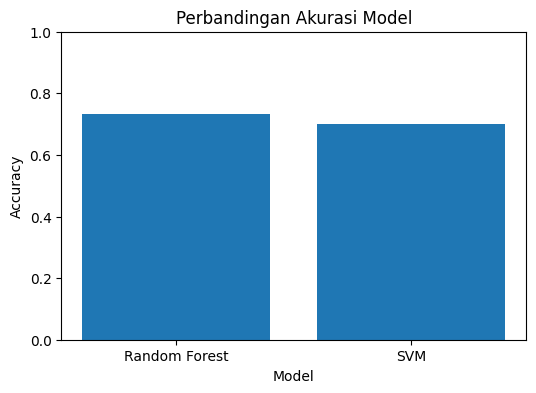

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(hasil['Model'], hasil['Accuracy'])

plt.title('Perbandingan Akurasi Model')
plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.ylim(0,1)

plt.show()

# Kesimpulan

Berdasarkan hasil eksperimen menggunakan dua algoritma Machine Learning yaitu Random Forest dan Support Vector Machine (SVM), diperoleh bahwa algoritma dengan nilai akurasi tertinggi dipilih sebagai model terbaik untuk melakukan prediksi penerimaan beasiswa pada dataset yang digunakan.